# 02 Exploratory Data Analysis

This notebook explores inspection distributions, trends over time, score behavior, and borough-level patterns in the filtered 2022 to 2025 data.

In [1]:
# Author: Jessica
# Loading cleaned data so this notebook runs independently

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_filtered_2022_2025 = pd.read_csv("shared_data/cleaned_inspections.csv", parse_dates=['INSPECTION DATE'])
print(df_filtered_2022_2025.shape)
df_filtered_2022_2025.head()

(257539, 27)


,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,40837042,MALECON RESTAURANT,Bronx,55925594,BROADWAY,NaN,7184325155,Latin American,2022-12-12,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,2.000000e+00,NaN,NaN
1,40380164,CUCHIFRITOS,Bronx,158,E. 188 TH ST,NaN,7183674500,Spanish,2022-01-24,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,0.000000,0.000000,NaN,NaN,NaN,NaN,2.000000e+00,NaN,NaN
2,41202725,DUNKIN,Queens,75-20,37 AVENUE,11372.0,7183975660,American,2024-08-05,No violations were recorded at the time of thi...,...,Cycle Inspection / Re-inspection,40.749077,-73.890546,403.0,25.0,28700.0,4029851.0,4.012860e+09,QN28,POINT (-73.890546005406 40.749076826787)
3,50108462,THE MAC SHACK,Brooklyn,320,MALCOLM X BOULEVARD,11233.0,7182109603,American,2024-06-15,No violations were recorded at the time of thi...,...,Inter-Agency Task Force / Initial Inspection,40.681852,-73.928857,303.0,36.0,29700.0,3047511.0,3.016810e+09,BK61,POINT (-73.928856784586 40.681851895564)
4,41241298,ALCHEMY,Brooklyn,56,5 AVENUE,11217.0,7186364385,American,2025-04-17,Violations were cited in the following area(s).,...,Cycle Inspection / Re-inspection,40.681290,-73.977163,306.0,39.0,12901.0,3018543.0,3.009320e+09,BK37,POINT (-73.9771631224 40.681289806446)


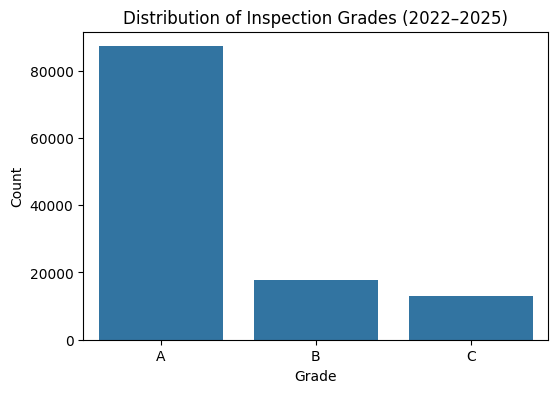

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df_filtered_2022_2025, x="GRADE", order=["A","B","C"])

plt.title("Distribution of Inspection Grades (2022–2025)")
plt.xlabel("Grade")
plt.ylabel("Count")

plt.show()

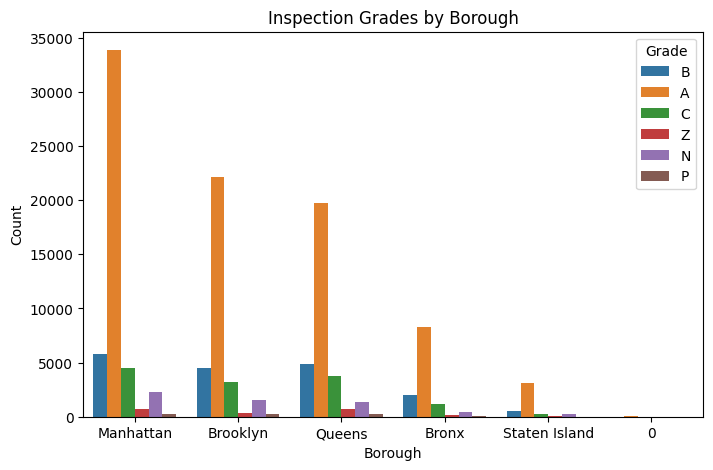

In [3]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_filtered_2022_2025,
    x="BORO",
    hue="GRADE",
    order=df_filtered_2022_2025["BORO"].value_counts().index
)

plt.title("Inspection Grades by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.legend(title="Grade")

plt.show()

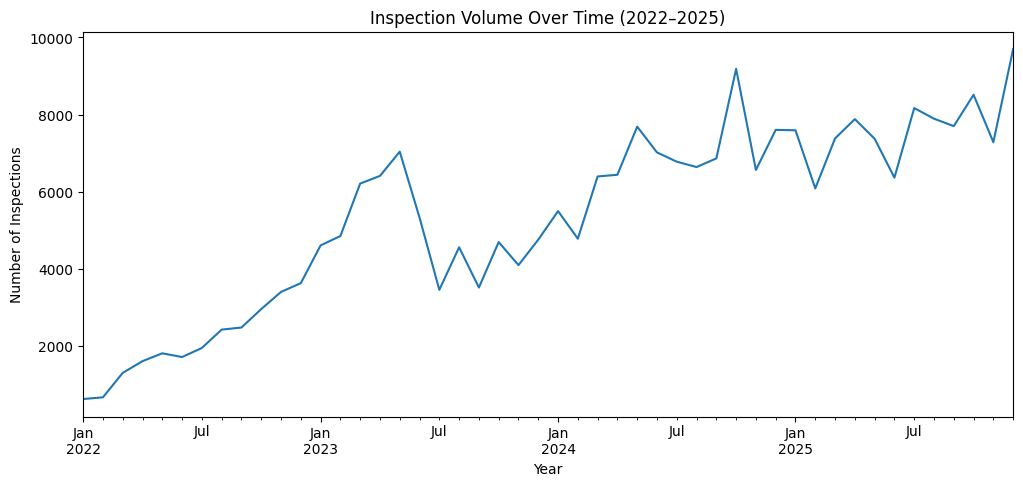

In [4]:
df_filtered_2022_2025["YearMonth"] = df_filtered_2022_2025["INSPECTION DATE"].dt.to_period("M")

monthly = df_filtered_2022_2025.groupby("YearMonth")["CAMIS"].count()

plt.figure(figsize=(12,5))
monthly.plot()

plt.title("Inspection Volume Over Time (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Inspections")

plt.show()

/tmp/ipykernel_14599/2833399416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


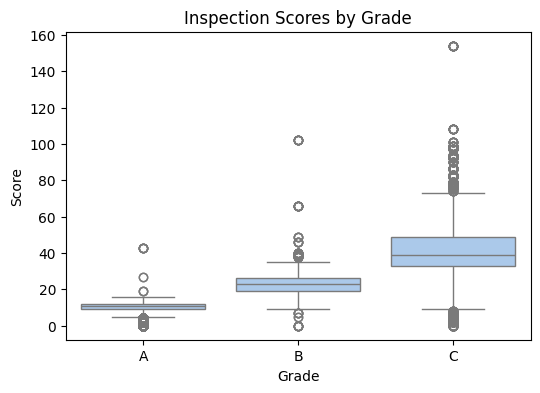

In [5]:
plt.figure(figsize=(6,4))

# lighten the boxplot by using a pastel version of the default blue
sns.boxplot(
    data=df_filtered_2022_2025,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"],
    palette=[sns.color_palette("pastel")[0]]*3  # same light blue for each grade
)

plt.title("Inspection Scores by Grade")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

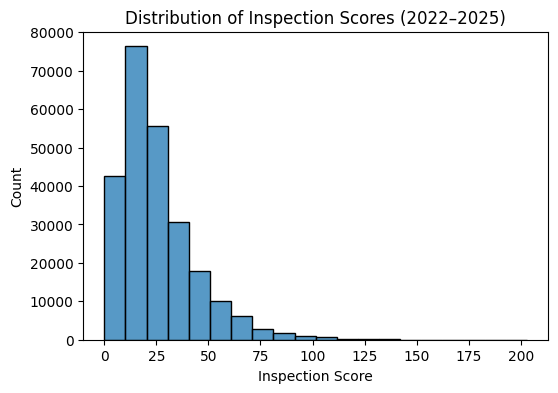

In [6]:
#Histogram of Score distribution (styled like the grade countplot)
plt.figure(figsize=(6,4))

# use seaborn histogram for consistent styling
sns.histplot(
    data=df_filtered_2022_2025,
    x="SCORE",
    bins=20,
    color=sns.color_palette()[0],  # default seaborn blue
    edgecolor="black",
    kde=False,
)

plt.title("Distribution of Inspection Scores (2022–2025)")
plt.xlabel("Inspection Score")
plt.ylabel("Count")

plt.show()

In [7]:
df_filtered_2022_2025['BORO'].unique()

df_Manhattan = df_filtered_2022_2025[
    df_filtered_2022_2025['BORO'] == 'Manhattan'
].copy()

df_Manhattan.describe()

,CAMIS,ZIPCODE,INSPECTION DATE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,9.498800e+04,93669.000000,94988,90239.000000,94546.000000,94546.000000,93227.000000,93231.000000,93231.000000,9.285100e+04,9.454600e+04
mean,4.795504e+07,10022.531777,2024-06-03 14:30:41.310481,24.361296,40.185494,-72.949276,105.084461,3.649484,10048.962180,1.037285e+06,9.916019e+08
min,3.019184e+07,10000.000000,2022-01-03 00:00:00,0.000000,0.000000,-74.018001,101.000000,1.000000,201.000000,1.000000e+06,1.000000e+00
25%,5.000155e+07,10010.000000,2023-07-20 00:00:00,12.000000,40.727717,-73.995154,103.000000,2.000000,4700.000000,1.010674e+06,1.004800e+09
50%,5.008947e+07,10017.000000,2024-07-23 00:00:00,20.000000,40.749641,-73.985596,105.000000,3.000000,9200.000000,1.028631e+06,1.008570e+09
75%,5.012770e+07,10027.000000,2025-04-17 00:00:00,32.000000,40.766056,-73.970749,107.000000,4.000000,13400.000000,1.061902e+06,1.013020e+09
max,5.018002e+07,11371.000000,2025-12-31 00:00:00,203.000000,40.872885,0.000000,164.000000,10.000000,31704.000000,1.799161e+06,1.270000e+09
std,3.833818e+06,31.064754,NaN,18.594379,4.780069,8.677128,3.021776,2.378405,6751.872166,3.612078e+04,1.342997e+08


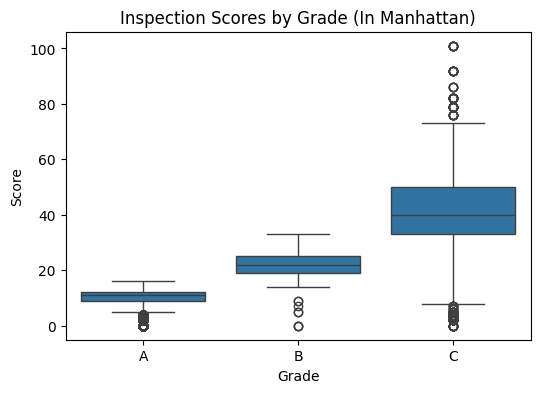

In [8]:
#Grading in Manhattan


plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Manhattan,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (In Manhattan)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()
#Showing the boxplot throughout the years

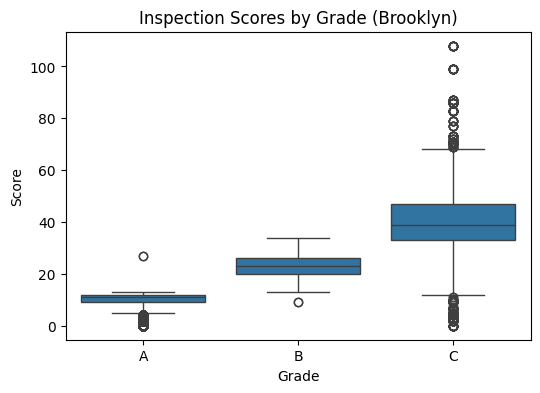

In [9]:
# checking borough values
df_filtered_2022_2025['BORO'].unique()

# filtering for Brooklyn
df_Brooklyn = df_filtered_2022_2025[
    df_filtered_2022_2025['BORO'].str.upper() == 'BROOKLYN'
].copy()

df_Brooklyn.describe()

# plotting
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Brooklyn,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (Brooklyn)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

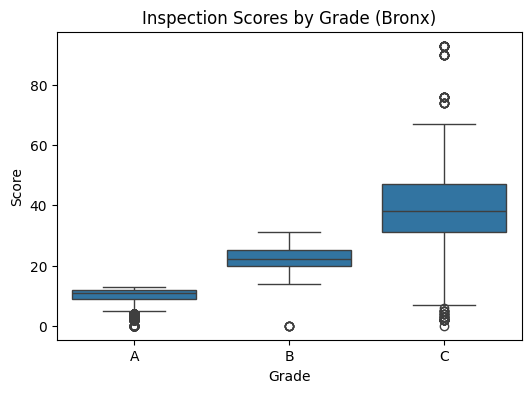

In [10]:

# checking borough values
df_filtered_2022_2025['BORO'].unique()

# filtering for Bronx
df_Bronx = df_filtered_2022_2025[
    df_filtered_2022_2025['BORO'].str.upper() == 'BRONX'
].copy()

df_Bronx.describe()

# plotting
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Bronx,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (Bronx)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

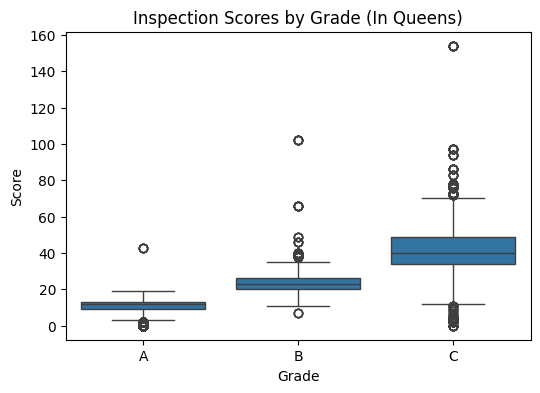

In [11]:
df_filtered_2022_2025.BORO.unique()
df_Queens = df_filtered_2022_2025[df_filtered_2022_2025['BORO'] == 'Queens'].copy()
df_Queens.describe()

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Queens,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (In Queens)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

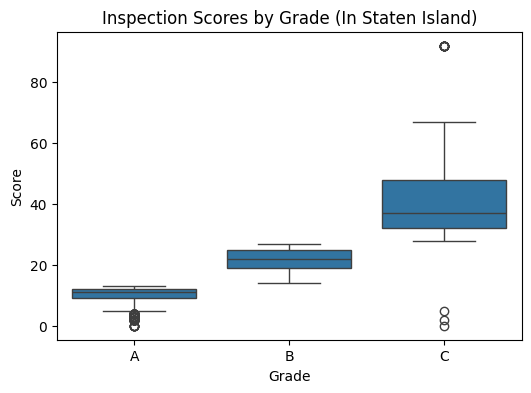

In [12]:
df_filtered_2022_2025.BORO.unique()
df_Staten_Island = df_filtered_2022_2025[df_filtered_2022_2025['BORO'] == 'Staten Island'].copy()
df_Staten_Island.describe()

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Staten_Island,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (In Staten Island)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()